In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [19]:
df = pd.read_csv("../data/creditcard.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26 

In [20]:
print(df["Class"].value_counts())
print(f"\nFraud %: {df['Class'].mean() * 100:.2f}%")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.17%


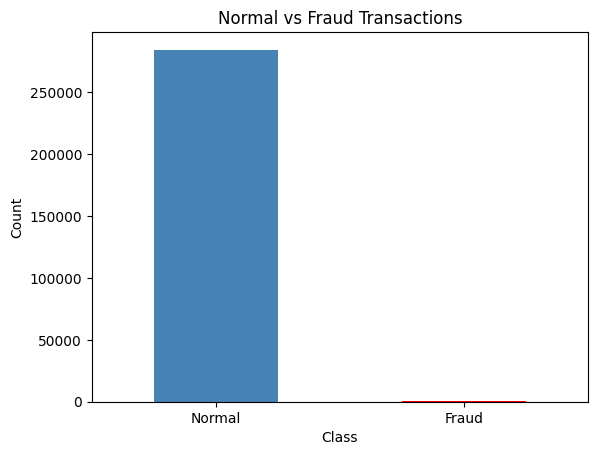

In [21]:
df["Class"].value_counts().plot(kind="bar", color=["steelblue", "red"])
plt.title("Normal vs Fraud Transactions")
plt.xticks([0, 1], ["Normal", "Fraud"], rotation=0)
plt.ylabel("Count")
plt.show()

In [22]:
print("Missing values:", df.isnull().sum().sum())
print("Columns:", df.columns.tolist())

Missing values: 0
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (227845, 30)
Test size: (56962, 30)


In [24]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42, eval_metric="logloss")
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [25]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))
print("AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUC Score: 0.9389517272862999


In [26]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [27]:
model_sm=XGBClassifier(random_state=42, eval_metrics="logloss")
model_sm.fit(X_train_sm, y_train_sm)
y_pred_sm=model_sm.predict(X_test)
print(classification_report(y_test, y_pred_sm, target_names=["Normal", "Fraud"]))
print("AUC Score:", roc_auc_score(y_test, model_sm.predict_proba(X_test)[:,1]))

c:\Users\abhin\fraud-detection-mlops\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:21:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.73      0.85      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962

AUC Score: 0.9799832109264639


In [28]:
import mlflow

mlflow.set_tracking_uri("file:///C:/Users/abhin/fraud-detection-mlops/mlruns")
mlflow.set_experiment("fraud-detection")
print("MLflow ready!")

MLflow ready!


In [32]:
import mlflow
import mlflow.xgboost

mlflow.set_experiment("fraud-detection")

with mlflow.start_run(run_name="XGBoost with SMOTE"):
    mlflow.log_param("model", "XGBoost')"
    mlflow.log_param("accuracy", "0.95")
    


print("MLflow ready!")

SyntaxError: '(' was never closed (3142465609.py, line 7)

In [33]:
with mlflow.start_run(run_name="xgboost-smote"):
    
    # Log parameters
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("smote", True)
    mlflow.log_param("test_size", 0.2)
    
    # Train
    model_tracked = XGBClassifier(random_state=42, eval_metric="logloss")
    model_tracked.fit(X_train_sm, y_train_sm)
    
    # Evaluate
    y_pred_tracked = model_tracked.predict(X_test)
    auc = roc_auc_score(y_test, model_tracked.predict_proba(X_test)[:,1])
    
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    # Log metrics
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("f1", f1_score(y_test, y_pred_tracked))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_tracked))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_tracked))
    
    # Save model
    mlflow.xgboost.log_model(model_tracked, "model")
    
    print(f"AUC: {auc:.4f}")
    print("Run logged to MLflow!")

2026/04/07 16:32:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


AUC: 0.9800
Run logged to MLflow!


In [34]:
print("Run this in terminal to see dashboard:")
print("mlflow ui")

Run this in terminal to see dashboard:
mlflow ui
